# Calculate-M0+noM0-Orbitrap-NO3

Input: .xlsx sheet containing averaged, calibrated M0 and no-M0 d-values and their uncertanties for each sample

Output: .xlsx file with sheets containing
    
    1. M0-referenced $\delta$-values for all measured isotopologues, averaged via the selected basepeaks
    2. Derived $\Delta$-values for triple-isotope and clumped-isotope quantities, calculated from the $\delta$-values in the previous sheet
    3. A summary of final $\delta$- and $\Delta$-values for reporting

In [1]:
import os
import numpy as np
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from datetime import datetime
current_datetime = datetime.now()
current_date_string = current_datetime.strftime("%Y-%m-%d")

# default colours
defcols = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
   

In [2]:
### INPUT CALIBRATED DATA FILEPATH ###
# excel sheet needs to have columns like 'd15N_M0' and 'd15N_M0_err' for each isotopologue ratio measured and one row per sample
file = 'FILENAME_HERE.xlsx'
sheet_name = 'Small deltas calibrated'

# load 
samples_cal_final = pd.read_excel(file,sheet_name=sheet_name,index_col='Unnamed: 0')

# display head
data = samples_cal_final.copy()
data.head()

,d15N_M0,d17O_M0,d18O_M0,d17O_15N,d18O_15N,d15N18O_15N,d18O18O_15N,D17O_M0,d15N_M0_err,d17O_M0_err,d18O_M0_err,d17O_15N_err,d18O_15N_err,d15N18O_15N_err,d18O18O_15N_err,D17O_M0_err,sample_name,blockname
0,0.00,0.05,0.06,NaN,NaN,NaN,NaN,0.02,0.00,0.00,0.00,NaN,NaN,NaN,NaN,0.00,C282,250117_079
1,0.00,0.05,0.06,NaN,NaN,NaN,NaN,0.02,0.00,0.00,0.00,NaN,NaN,NaN,NaN,0.00,C282,250117_219
2,0.00,0.05,0.06,NaN,NaN,NaN,NaN,0.02,0.00,0.00,0.00,NaN,NaN,NaN,NaN,0.00,C282,250117_185
3,0.00,0.05,0.06,NaN,NaN,NaN,NaN,0.02,0.00,0.00,0.00,NaN,NaN,NaN,NaN,0.00,C282,250117_179
4,0.00,0.05,0.06,NaN,NaN,NaN,NaN,0.02,0.00,0.00,0.00,NaN,NaN,NaN,NaN,0.00,C282,250117_131


In [3]:
### joining and averaging M0 and no-M0 injections for each sample

if True:
    # averaging the replicate measurements, generation of uncertainty values per sample

    def averaging(df):
        df_av = pd.Series(dtype='float')

        for col in df.columns:
            if (not col.endswith('_err')) and (col.startswith(('d','D'))):
                df_col = df[col].dropna()

                # mean value
                av = df_col.mean()

                # standard error of the mean
                n = len(df_col)
                sem = df_col.std() / np.sqrt(n) if n > 0 else np.nan

                # calibration error: just average available _err values
                if col + '_err' in df.columns:
                    err_cal = df.loc[df_col.index, col + '_err'].mean()
                else:
                    err_cal = np.nan

                # store results
                df_av[col] = av
                df_av[col + '_n'] = n
                df_av[col + '_sem'] = sem
                df_av[col + '_err_cal'] = err_cal

        return df_av

    # construction dataframe, apply averaging function
    data_av=pd.DataFrame(columns=[col for col in data.columns if (not col.endswith('_err')) and (col.startswith(('d','D')))]+
                        [col+'_n' for col in data.columns if (not col.endswith('_err')) and (col.startswith(('d','D')))]  +
                        [col+'_sem' for col in data.columns if (not col.endswith('_err')) and (col.startswith(('d','D')))] +
                        [col+'_err_cal' for col in data.columns if (not col.endswith('_err')) and (col.startswith(('d','D')))] ) 
    for spl,df in data.groupby('sample_name'):
         data_av.loc[spl,:] = averaging(df)

    # total error = sum in quadrature of sem and calibration errors
    for col in data_av.columns:
        if not col.endswith(('_err_cal','_sem','_n')) and col.startswith(('d','D')):
            err_tot = (data_av[col+'_sem']**2 + data_av[col+'_err_cal']**2 )**0.5
            data_av[col+'_err']=err_tot

    # drop any samples you like from output
    if False:
        to_drop = []
        data_av = data_av.loc[[spl for spl in data_av.index if spl not in to_drop]]

    # drop standards
    if True:
        to_drop_start = ('USGS','SMIF')
        data_av = data_av.loc[[spl for spl in data_av.index if not spl.startswith(to_drop_start)]]


    # display averages     
    dcols = [col for col in data_av.columns if not col.endswith(('sem','err_cal','err','_n'))]
    disp=pd.DataFrame(columns=dcols)
    for col in dcols:
        avs = data_av[[c for c in data_av.columns if c.startswith(col)]].mean()
        avs.index=['val','n','sem','err_cal','err']
        disp[col] = avs 

    print('Averages:\n')
pd.concat([disp.T[['val','sem','err_cal','err']]*1e3 ,disp.T['n']],axis=1)


Averages:



,val,sem,err_cal,err,n
d15N_M0,4.18,0.53,0.28,0.61,6.00
d17O_M0,57.97,0.93,1.02,1.39,6.00
d18O_M0,67.90,0.56,0.50,0.76,6.00
d17O_15N,52.93,0.42,0.50,0.66,6.00
d18O_15N,62.59,0.35,0.53,0.64,6.00
d15N18O_15N,68.76,1.53,1.22,1.97,6.00
d18O18O_15N,132.54,2.00,1.83,2.76,6.00
D17O_M0,22.66,0.95,0.96,1.37,6.00


## Calculations of $\delta$-values relative to M0 

Translation of no-M0 $\delta$-values to M0 $\delta$-values

Calculation:
#### $\delta(\frac{X}{M_0})+1 = \frac{\delta(\frac{X}{B})+1}{\delta(\frac{B}{M_0})+1}$
For any substituted isotopologue $X$ and any basepeak $B$ measured in both M0 and no-M0 experiments

The calculation is made for each possible basepeak ($B=$ 15N, 17O, 18O) for every substituted isotopologue $X$, for every sample/standard, uncertainties are propagated using a Monte-Carlo scheme, accounting for significant covariances between (e.g.) 17O/15N and 18O/15N ratios.

Sets of mean d-values and covariance matrices are generated for each sample


blabla
2. A weighted average $\delta$-value is calculated for every substituted isotopologue, using the basepeaks chosen in 'averaging_dict'. Average is weighted by uncertainty (weights = $1/\sigma^2$)



The dataframe 'small_deltas' contains the weighted average value and its error for each substituted isotopologue, for each sample

In [4]:
data_av = data_av.dropna(axis=1) # drop cols with nan; calc doesn't work if nans present in data

# variables for Monte-Carlo sampling
base_vars = [col for col in data_av.columns if col.endswith(('15N','M0')) and not col.startswith('D')]

# number of Monte Carlo iterations
n_mc = 100

# prepare dataframes for results
mean_derived = pd.DataFrame(columns =[ 'd15N_noM0-18O', 'd15N_noM0-17O', 
                                      'd18O_noM0-15N', 'd18O_noM0-17O', 
                                      'd17O_noM0-15N', 'd17O_noM0-18O', 
                                      'd15N18O_noM0-15N', 'd15N18O_noM0-18O', 'd15N18O_noM0-17O',
                                      'd18O18O_noM0-15N', 'd18O18O_noM0-17O','d18O18O_noM0-18O', 
                                      'd15N_M0', 'd17O_M0', 'd18O_M0'])
cov_derived = []

# function calculates all M0-relative deltas, via all three basepeaks from a base sample row
def compute_derived_deltas(base_row):
    d = {}
    d['d15N_noM0-18O'] = (base_row['d18O_M0']+1)/(base_row['d18O_15N']+1)-1
    d['d15N_noM0-17O'] = (base_row['d17O_M0']+1)/(base_row['d17O_15N']+1)-1
    d['d18O_noM0-15N'] = (base_row['d18O_15N']+1)*(base_row['d15N_M0']+1)-1
    d['d18O_noM0-17O'] = (base_row['d18O_15N']+1)*(base_row['d17O_M0']+1)/(base_row['d17O_15N']+1)-1
    d['d17O_noM0-15N'] = (base_row['d17O_15N']+1)*(base_row['d15N_M0']+1)-1
    d['d17O_noM0-18O'] = (base_row['d17O_15N']+1)*(base_row['d18O_M0']+1)/(base_row['d18O_15N']+1)-1
    d['d15N18O_noM0-15N'] = (base_row['d15N18O_15N']+1)*(base_row['d15N_M0']+1)-1
    d['d15N18O_noM0-18O'] = (base_row['d15N18O_15N']+1)*(base_row['d18O_M0']+1)/(base_row['d18O_15N']+1)-1
    d['d15N18O_noM0-17O'] = (base_row['d15N18O_15N']+1)*(base_row['d17O_M0']+1)/(base_row['d17O_15N']+1)-1
    d['d18O18O_noM0-15N'] = (base_row['d18O18O_15N']+1)*(base_row['d15N_M0']+1)-1
    d['d18O18O_noM0-18O'] = (base_row['d18O18O_15N']+1)*(base_row['d18O_M0']+1)/(base_row['d18O_15N']+1)-1
    d['d18O18O_noM0-17O'] = (base_row['d18O18O_15N']+1)*(base_row['d17O_M0']+1)/(base_row['d17O_15N']+1)-1
    # add the unchanged M0 measurements too
    for v in ['d15N_M0','d17O_M0','d18O_M0']:
        d[v] = base_row[v]
    return d

# treat samples one by one in loop
for idx in data_av.index:

    # covariance matrix for that sample (n_base x n_base)
    C_base = pd.DataFrame(0.0,columns=base_vars,index=base_vars)
    # i=j covariance terms are simple variance
    for v in base_vars:
        C_base.loc[v,v]=data_av.loc[idx,v+'_err']**2
    # estimates of i!=j covariance terms where significant (no-M0 ratios of 15N, 18O & 17O peaks) -> using err(18/15)^2 = err(18)^2 + err(15)^2 and err(X)^2 = 1/n(X)
    abundance={'15N':3.614e-3,
                '18O':6.098e-3,
                '17O':1.130e-3}
    C_base.loc['d17O_15N','d18O_15N'] = C_base.loc['d18O_15N','d18O_15N']*abundance['15N']/(abundance['15N']+abundance['18O'])
    C_base.loc['d18O_15N','d17O_15N'] = C_base.loc['d18O_15N','d18O_15N']*abundance['15N']/(abundance['15N']+abundance['18O'])
    C_base = C_base.dropna(axis=0, how='any')
    C_base = C_base[C_base.index]
    base_vars = C_base.columns # update base vars after dropnan

    # mean for MC sampling = d-value measurement
    base_mean = data_av.loc[idx, base_vars].astype(float).values
    
    # MC calculations, drawing from covarying distribution
    for nn in range(n_mc):
        
        # sample from multivariate normal
        base_samples = np.random.multivariate_normal(base_mean, C_base.loc[base_vars, base_vars].values, size=n_mc)

        # apply calculation function above to each MC sample, make a df with n_mc rows and one column for each d-value calculation
        derived_samples = []
        for row in base_samples:
            base_row = dict(zip(base_vars,row))
            derived = compute_derived_deltas(base_row)
            derived_samples.append(derived)
        derived_df = pd.DataFrame(derived_samples)

    # compute covariance matrix of derived delta-values
    mean_derived.loc[idx] = np.mean(derived_df, axis=0)
    cov_derived += [np.cov(derived_df, rowvar=False)]  # shape: (n_derived, n_derived)

# covariance dict, one matrix per sample
calc_deltas_cov = dict(zip(data_av.index,cov_derived))
# df with mean MC values for each sample
calc_deltas_mc = mean_derived.copy()

# display means
print(calc_deltas_mc*1e3)


      d15N_noM0-18O  d15N_noM0-17O  d18O_noM0-15N  d18O_noM0-17O  \
C282           3.18           0.40          60.80          59.83   
C285           3.71           3.76          66.70          67.52   
C286           2.83           1.29          63.71          63.77   
C290           4.92           7.21          66.84          69.66   
C291           3.05           1.12          66.24          64.57   
C292           2.20           4.19          67.98          69.29   
C293           8.01           6.80          71.37          71.43   
C294           4.18           3.19          67.97          68.09   
C295           5.53           7.11          69.56          72.30   
C296           8.07           6.29          65.22          65.40   
C297           7.29           6.22          69.20          69.46   
C298           4.21           4.19          67.00          65.71   
C300           7.17           8.09          67.15          69.89   
C301           5.76           7.39          68.1

## Weighted averaging over basepeaks to give a 'best-estimate' of each $\delta$-value

Specify which basepeaks to include in the calculation and how to name the outputs in averaging_dict

Generates one value and one error for each entry in averaging_dict for each sample

In [8]:
small_deltas = pd.DataFrame(index=data_av.index)

# Compute weighted averages and uncertainties from averaging_dict
averaging_dict = {'d15N_average-M0+18O':['d15N_M0','d15N_noM0-18O'],
                  'd15N_M0':['d15N_M0'],
                  # 'd15N_average-all':['d15N_M0','d15N_noM0-18O','d15N_noM0-17O'],
                 'd17O_average-noM0':['d17O_noM0-15N','d17O_noM0-18O'],
                  'd17O_M0':['d17O_M0'],
                 # 'd17O_average-all':['d17O_M0','d17O_noM0-15N','d17O_noM0-18O'],
                 'd18O_average-M0+15N':['d18O_M0','d18O_noM0-15N'],
                  'd18O_M0':['d18O_M0'],
                 # 'd18O_average-all':['d18O_M0','d18O_noM0-15N','d18O_noM0-17O'],
                 'd15N18O_average-15N+18O':['d15N18O_noM0-15N','d15N18O_noM0-18O'],
                  # 'd15N18O_average-all':['d15N18O_noM0-15N','d15N18O_noM0-18O','d15N18O_noM0-17O'],
                  'd18O18O_average-15N+18O':['d18O18O_noM0-15N','d18O18O_noM0-18O'],
                  # 'd15N18O_average-all':['d15N18O_noM0-15N','d15N18O_noM0-18O','d15N18O_noM0-17O']
                 }


for avg_name, delta_list in averaging_dict.items():
    values = calc_deltas_mc[delta_list]
    colids = [calc_deltas_mc.columns.get_loc(col) for col in delta_list]

    for sample in data_av.index:
        # values
        vals = values.loc[sample].values

        # covariance matrix subset
        C = calc_deltas_cov[sample]
        C_sub = C[np.ix_(colids, colids)]

        # weighted mean for each key in averaging dict (weights = 1/variances)
        w = 1 / np.diag(C_sub)
        av = np.sum(w * vals) / np.sum(w)

        # error on weigted mean
        sigma2 = np.sum(np.outer(w, w) * C_sub) / (np.sum(w)**2)
        sigma = np.sqrt(sigma2)

        small_deltas.loc[sample, avg_name] = av
        small_deltas.loc[sample, avg_name+'_err'] = sigma

print(small_deltas*1e3)


      d15N_average-M0+18O  d15N_average-M0+18O_err  d15N_M0  d15N_M0_err  \
C282                 1.95                     0.39     1.32         0.51   
C285                 3.21                     0.55     2.99         0.68   
C286                 1.91                     0.65     1.23         0.82   
C290                 4.68                     0.51     4.55         0.63   
C291                 2.72                     0.36     2.68         0.38   
C292                 2.84                     0.46     2.97         0.49   
C293                 7.32                     0.56     6.74         0.76   
C294                 3.23                     0.41     3.08         0.42   
C295                 4.72                     0.44     4.54         0.51   
C296                 6.90                     0.53     6.12         0.64   
C297                 6.37                     0.60     5.98         0.67   
C298                 5.14                     0.52     5.40         0.55   
C300        

### QC: Plots of $\delta(X/M_0)$ for each basepeak $B$ (for M0+no-M0 data only)
Check that the basepeak calculations do not disagree with each other much beyond their error bars. Disagreement between basepeaks may indicate bad measurements or calibrations.

/var/folders/rr/bz6rnlcn09b6b2ttxx8h8x5m0000gn/T/ipykernel_83590/4120116434.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


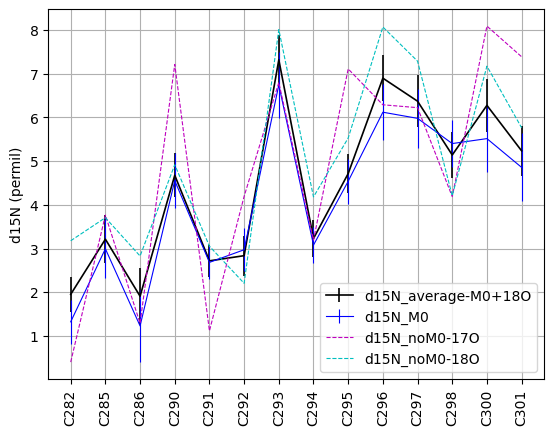

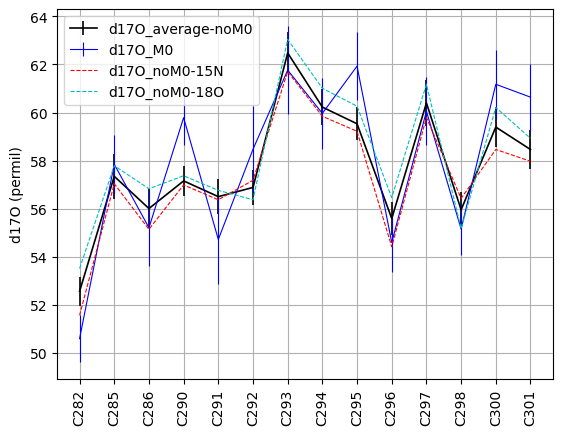

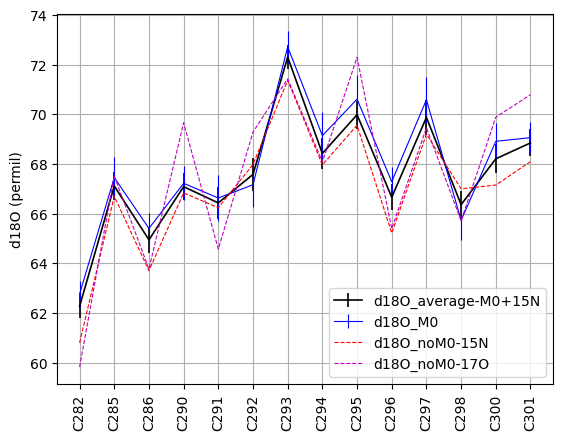

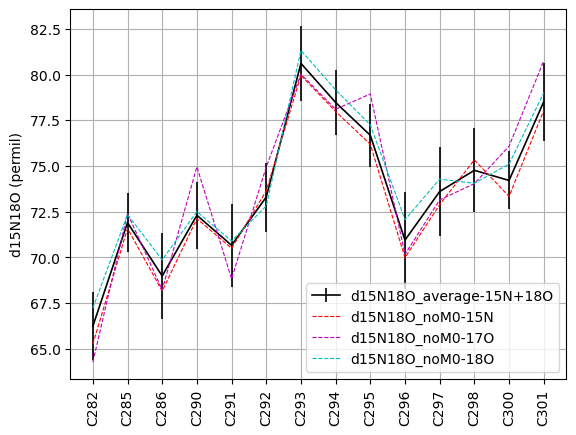

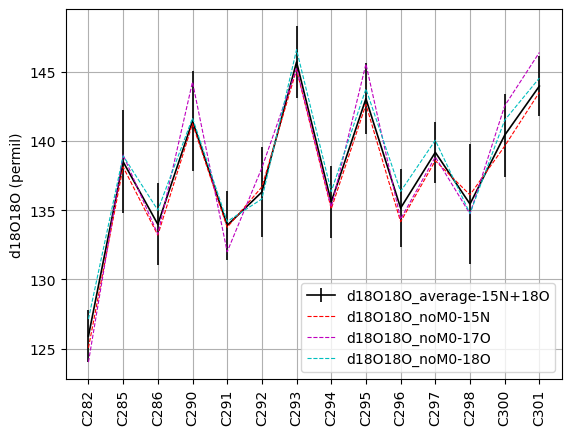

In [9]:
calc_deltas_c = calc_deltas_mc[calc_deltas_mc.columns.difference(small_deltas.columns)]
all_deltas = small_deltas.join(calc_deltas_c)

data_plot = all_deltas 

# plots for each little delta
for delta in pd.Series([col.split('_')[0] for col in data_plot.columns]).unique():
    fig,ax=plt.subplots()
    cols = [col for col in data_plot.columns if col.startswith(delta+'_') and not col.endswith('_err')]
    for col in cols:
        if col.split('_')[1].startswith('average'):
            ls='-';lw=1.2;c='k'
        elif col.split('_')[1]=='M0':
            ls='-';lw=0.8;c='b'
        elif col.split('-')[-1]=='15N':
            ls='--';lw=0.8;c='r'
        elif col.split('-')[-1]=='18O':
            ls='--';lw=0.8;c='c'
        elif col.split('-')[-1]=='17O':
            ls='--';lw=0.8;c='m'
        if col+'_err' in data_plot.columns:
            ax.errorbar(x=data_plot.index,y=data_plot[col]*1e3,yerr=data_plot[col+'_err']*1e3,ls=ls,lw=lw,c=c,label=col)
        else:
            ax.errorbar(x=data_plot.index,y=data_plot[col]*1e3,ls=ls,lw=lw,c=c,label=col)

    ax.set_ylabel(delta+' (permil)')
    ax.legend()
    ax.grid()
    ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


## Calculation of derived $\Delta$-values

From 'best estimate' $\delta$-values, following well-known formulae

In [10]:
# capital Deltas, value and propograted error

def calc_D17O(d17data,d17err, d18data,d18err):
    val = d17data - 0.52*d18data
    err = (d17err**2+(0.52*d18err)**2)**0.5
    return pd.DataFrame({'D17O':val,'D17O_err':err})

def calc_D15N18O(d1518data,d1518err, d15data,d15err, d18data,d18err):
    val = (1+d1518data)/((1+d15data)*(1+d18data)) -1
    err = (d1518err**2)**0.5     # removed both denominator error terms to account for covariance via 15N/M0 and 18O/M0 which are involved in top and bottom of fraction
    return pd.DataFrame({'D15N18O':val,'D15N18O_err':err})

def calc_D18O18O(d1818data,d1818err, d18data,d18err):
    val = (1+d1818data)/((1+d18data)*(1+d18data)) -1
    err = (d1818err**2 + d18err**2)**0.5 # removed one denominator error term to account for covariance via 18O/M0 which is involved in top and bottom of fraction
    return pd.DataFrame({'D18O18O':val,'D18O18O_err':err})

derived_deltas=pd.DataFrame()


derived_deltas[['D17O','D17O_err']] = calc_D17O(small_deltas['d17O_average-noM0'],small_deltas['d17O_average-noM0_err'],
                                                    small_deltas['d18O_average-M0+15N'],small_deltas['d18O_average-M0+15N_err'])
# M0-only D17O
derived_deltas[['D17O_M0','D17O_M0_err']] = calc_D17O(small_deltas['d17O_M0'],small_deltas['d17O_M0_err'],
                                                small_deltas['d18O_M0'],small_deltas['d18O_M0_err'])

derived_deltas[['D15N18O','D15N18O_err']] = calc_D15N18O(small_deltas['d15N18O_average-15N+18O'],small_deltas['d15N18O_average-15N+18O_err'],
                                                         small_deltas['d15N_average-M0+18O'],small_deltas['d15N_average-M0+18O_err'],
                                                         small_deltas['d18O_average-M0+15N'],small_deltas['d18O_average-M0+15N_err'])

derived_deltas[['D18O18O','D18O18O_err']] = calc_D18O18O(small_deltas['d18O18O_average-15N+18O'],small_deltas['d18O18O_average-15N+18O_err'],
                                                         small_deltas['d18O_average-M0+15N'],small_deltas['d18O_average-M0+15N_err'])

# display
derived_deltas*1e3

,D17O,D17O_err,D17O_M0,D17O_M0_err,D15N18O,D15N18O_err,D18O18O,D18O18O_err
C282,20.19,0.64,17.97,1.01,1.77,1.85,-2.23,1.94
C285,22.45,0.98,22.78,1.31,1.27,1.62,-0.20,3.78
C286,22.24,0.87,21.20,1.61,1.88,2.34,-0.12,3.02
C290,22.28,0.69,24.84,1.17,0.21,1.84,2.44,3.67
C291,21.96,0.80,20.08,1.91,1.24,2.26,-2.97,2.59
C292,21.75,0.81,23.55,1.84,2.51,1.89,-2.99,3.35
C293,24.88,0.89,23.95,1.86,0.43,2.04,-3.57,2.65
C294,24.65,0.81,24.01,1.57,6.16,1.79,-5.20,2.67
C295,23.14,0.74,25.22,1.52,1.53,1.73,-1.57,2.62
C296,20.94,0.73,19.61,1.26,-2.86,2.65,-2.29,2.85


## Compilation into single DataFrame, pooled final uncertainties
Reports values for:

- Averaged d15N, D17O, d18O, D15N18O, D18O18O

In [11]:

# compile averaged small deltas and derived deltas into a single dataframe
data_summary = pd.DataFrame()

# select which small deltas to report in summary dataframe
small_deltas_to_report = ['d15N','d15N_err','d18O','d18O_err']
small_d_cols = [col for col in small_deltas.columns if (col.split('_')[1].startswith('average')) & (col.startswith(tuple(( d+'_' for d in small_deltas_to_report))))]
derived_D_cols = [col for col in derived_deltas.columns.tolist() if not col.startswith('D17O_M0')]

# join in single DataFrame
data_summary[small_deltas_to_report]=small_deltas[small_d_cols]
data_summary[derived_D_cols]=derived_deltas[derived_D_cols]

# calculation pooled error for raw deltas
cols = [ col for col in data_summary.columns if col.endswith('err')]
rows = [ row  for row in data_summary.index ]
errs = data_summary.loc[rows,cols]
pooled_err_final = (np.sum(errs**2,axis=0)/len(errs.index))**0.5
print('Pooled final errors\n',pooled_err_final*1e3)

# display
print('\nFinal, calibrated delta- and Delta-values')
data_summary[[col for col in data_summary.columns if not col.endswith('_err')]]*1e3


Pooled final errors
 d15N_err      0.52
d18O_err      0.58
D17O_err      0.83
D15N18O_err   2.06
D18O18O_err   3.01
dtype: float64

Final, calibrated delta- and Delta-values


,d15N,d18O,D17O,D15N18O,D18O18O
C282,1.95,62.27,20.19,1.77,-2.23
C285,3.21,67.12,22.45,1.27,-0.20
C286,1.91,64.95,22.24,1.88,-0.12
C290,4.68,67.09,22.28,0.21,2.44
C291,2.72,66.43,21.96,1.24,-2.97
C292,2.84,67.58,21.75,2.51,-2.99
C293,7.32,72.30,24.88,0.43,-3.57
C294,3.23,68.43,24.65,6.16,-5.20
C295,4.72,69.98,23.14,1.53,-1.57
C296,6.90,66.66,20.94,-2.86,-2.29


## Plot final values

/var/folders/rr/bz6rnlcn09b6b2ttxx8h8x5m0000gn/T/ipykernel_83590/881352070.py:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


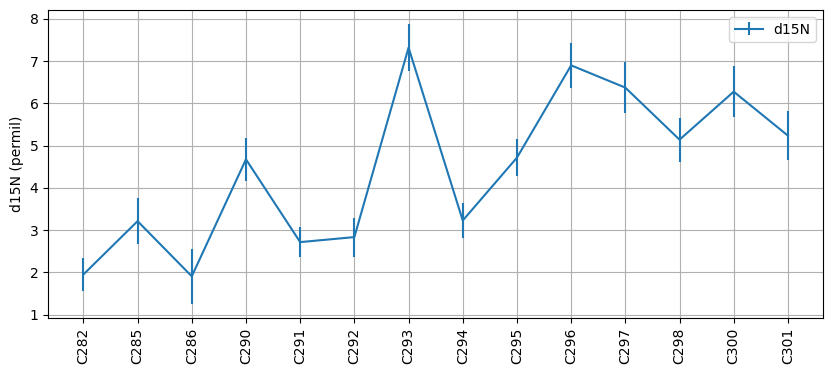

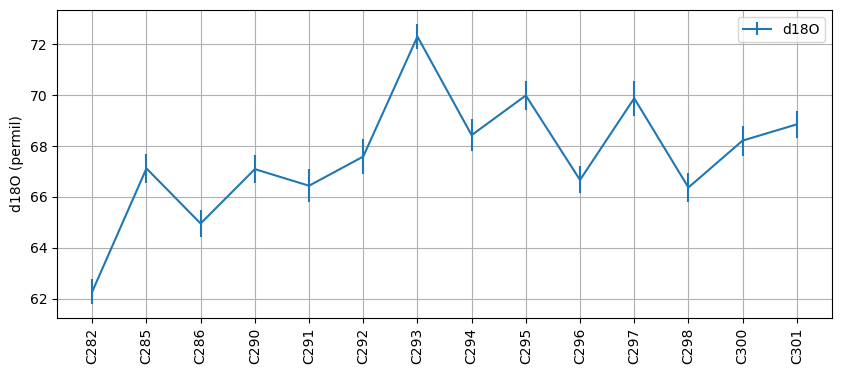

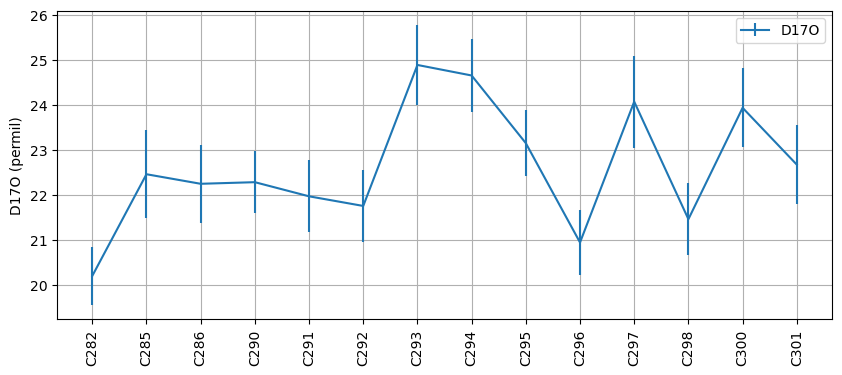

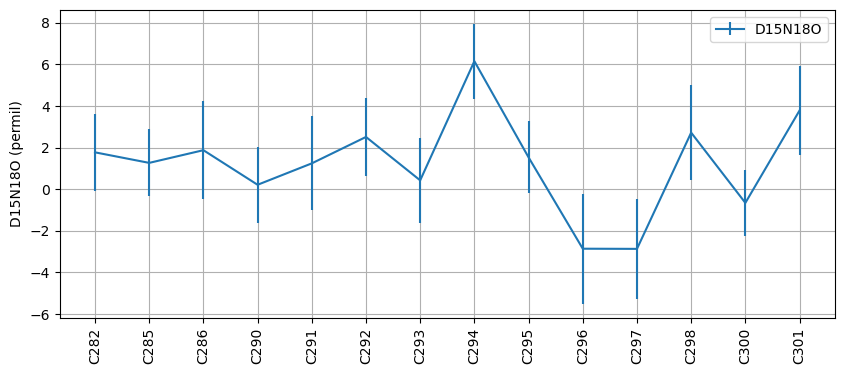

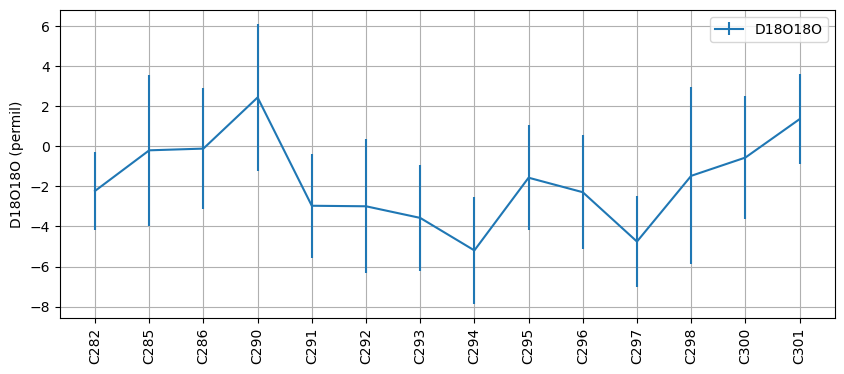

In [12]:
data_plot = data_summary
    
cols = pd.Series([col for col in data_plot.columns if not col.endswith('_err')]).unique()
    
# plots for each delta
for delta in cols:
    fig,ax=plt.subplots(figsize=[10,4])
    ax.errorbar(x=data_plot.index, y=data_plot[delta]*1e3,
               yerr=data_plot[delta+'_err']*1e3, label=delta)
   
    ax.set_ylabel(delta+' (permil)')
    ax.grid()
    ax.legend()
    ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

## Save all steps to excel file

In [13]:
output_file = os.getcwd().split('/')[-1]+'_final_'+current_date_string+'.xlsx'

to_save = {
           'Small deltas M0 calculations':small_deltas,
           'Derived deltas':derived_deltas,
           'Reported deltas':data_summary,
           }

for sheet_name, df in to_save.items():
    # Check if the file exists
    if not os.path.exists(os.path.join(output_file)):
        # If the file doesn't exist, create a new ExcelWriter object without mode='a'
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('Excel file created:',os.path.join(output_file),'\nNew sheet added to',output_file,':',sheet_name)
    else:
        # If the file exists, create an ExcelWriter object with mode='a' to append to the existing file
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl', mode='a',if_sheet_exists='replace') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('New sheet added to',output_file,':',sheet_name)

Excel file created: mar26_final_2026-04-10.xlsx 
New sheet added to mar26_final_2026-04-10.xlsx : Small deltas M0 calculations
New sheet added to mar26_final_2026-04-10.xlsx : Derived deltas
New sheet added to mar26_final_2026-04-10.xlsx : Reported deltas
